<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning_study/blob/main/CNN_image_classification_RockPaperScissors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Rock Paper Scissor Image Classification - CNN**

---

![image](https://machinethink.net/images/coreml-training/Classes@2x.jpg)

Source image: [machinethink.net](https://machinethink.net/blog/coreml-training-part2/)

**Context**

This project implements a multi-class image classification model using a Convolutional Neural Network (CNN) to automatically recognize hand gestures representing:

* Rock

* Paper

* Scissors

The goal is to train a deep learning model that can classify an input image into one of these three categories.

This is a classic supervised learning problem where:

* Input → RGB image (150 × 150 × 3)

* Output → One of 3 classes (rock, paper, scissors)

**Convolutional Neural Network (CNN)**

A Convolutional Neural Network (CNN) is a type of deep neural network designed primarily for processing grid-structured data such as images. Traditional machine learning struggles with raw pixel data because
*  high dimensionality
* spatial correlations between pixels.

While CNN uses convolutional layers to automatically extract spatial features (e.g., edges, textures, shapes) through local connections and shared weights, making it more efficient than fully connected networks for visual tasks.

**Initial setup**

Before running the experiment, We will download the rock, paper, and scissors data.

You can get the dataset [here](http://bit.ly/2kbV92O)

In [1]:
# Importing libraries
import tensorflow as tf # Deeplearning frame work
from tensorflow import keras # Model building
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# style
plt.style.use('ggplot')


**Downloading the dataset**

In [3]:
# Downloading the data

# Training set
!wget --no-check-certificate \
https://storage.googleapis.com/learning-datasets/rps.zip \
-O /tmp/rps.zip

# Testing and validation files
!wget --no-check-certificate \
https://storage.googleapis.com/learning-datasets/rps-test-set.zip \
-O /tmp/rps-test-set.zip

--2026-03-02 19:40:51--  https://storage.googleapis.com/learning-datasets/rps.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.195.207, 172.253.117.207, 142.250.99.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.195.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 200682221 (191M) [application/zip]
Saving to: ‘/tmp/rps.zip’

/tmp/rps.zip        100%[===================>] 191.38M   102MB/s    in 1.9s    

2026-03-02 19:40:53 (102 MB/s) - ‘/tmp/rps.zip’ saved [200682221/200682221]

--2026-03-02 19:40:53--  https://storage.googleapis.com/learning-datasets/rps-test-set.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.195.207, 172.253.117.207, 142.250.99.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.195.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29516758 (28M) [application/zip]
Saving to: ‘/tmp/rps-test-set.zip’

/tmp/rps

**Unzipping files**

We will unzip files and store it in the 'tmp' or temporary folder in colab.

In [4]:
# Unzip files to a temp directory

import os          # For directory operations
import zipfile     # For extracting zip files

local_zip = '/tmp/rps.zip'     # Path to training zip file
zip_ref = zipfile.ZipFile(local_zip, 'r')  # Open zip file in read mode
zip_ref.extractall('/tmp/')    # Extract all contents into /tmp/
zip_ref.close()                # Close zip file

local_zip = '/tmp/rps-test-set.zip'  # Path to test zip
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/')
zip_ref.close()

**Setting directory**

In [5]:
# Inspect dataset

# Set directory location
rock_dir = os.path.join('/tmp/rps/rock')          # Directory for rock images
paper_dir = os.path.join('/tmp/rps/paper')        # Directory for paper images
scissors_dir = os.path.join('/tmp/rps/scissors')  # Directory for scissor images

# Count total images per class
print('total training rock images:', len(os.listdir(rock_dir)))
print('total training paper images:', len(os.listdir(paper_dir)))
print('total training scissors images:', len(os.listdir(scissors_dir)))

# Get list of filenames
rock_files = os.listdir(rock_dir)
print(rock_files[:10]) # Show 10 first filenames

paper_files = os.listdir(paper_dir)
print(paper_files[:10])

scissors_files = os.listdir(scissors_dir)
print(scissors_files[:10])

total training rock images: 840
total training paper images: 840
total training scissors images: 840
['rock06ck02-077.png', 'rock04-052.png', 'rock02-056.png', 'rock06ck02-032.png', 'rock04-112.png', 'rock06ck02-113.png', 'rock07-k03-005.png', 'rock06ck02-045.png', 'rock02-089.png', 'rock03-072.png']
['paper02-035.png', 'paper06-040.png', 'paper07-109.png', 'paper05-059.png', 'paper06-085.png', 'paper01-108.png', 'paper06-021.png', 'paper02-013.png', 'paper03-038.png', 'paper03-062.png']
['scissors01-012.png', 'scissors02-112.png', 'scissors02-009.png', 'scissors04-091.png', 'scissors02-017.png', 'scissors02-078.png', 'scissors03-035.png', 'testscissors03-070.png', 'scissors04-005.png', 'scissors02-026.png']


This step will create folders with sub-fulder of each categories.



When training in TensorFlow using an image data generator, we can get the labels based on the name of their parent directory

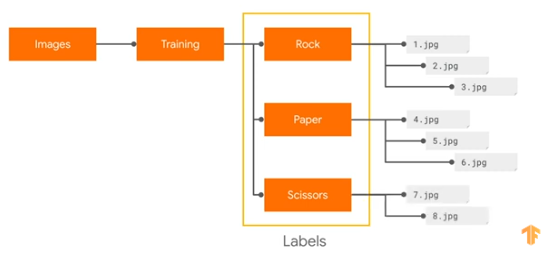

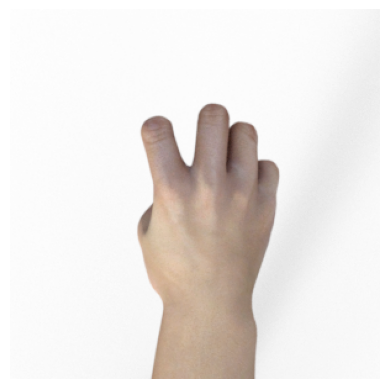

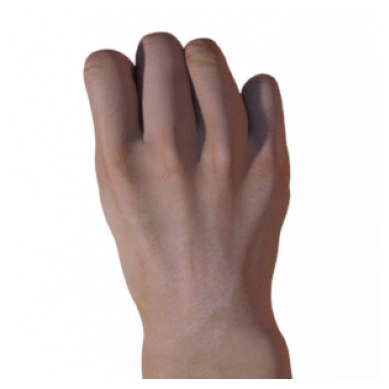

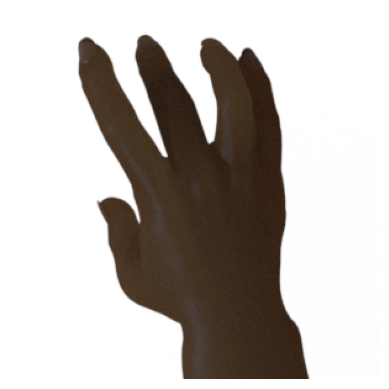

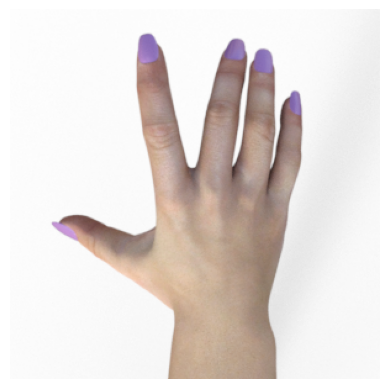

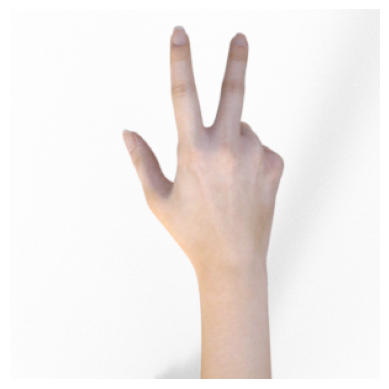

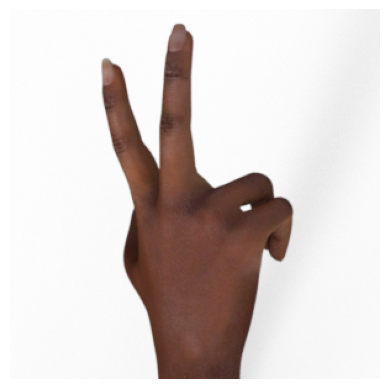

In [8]:
# Display sample images

%matplotlib inline
# Ensures plots display inside notebook

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pic_index = 2 # Index for selecting images

# Select two rock images
next_rock = [os.path.join(rock_dir, fname)
                for fname in rock_files[pic_index-2:pic_index]]

# Select two paper images
next_paper = [os.path.join(paper_dir, fname)
                for fname in paper_files[pic_index-2:pic_index]]

# Select two scissor images
next_scissors = [os.path.join(scissors_dir, fname)
                for fname in scissors_files[pic_index-2:pic_index]]

# Loop displaying images
for i, img_path in enumerate(next_rock+next_paper+next_scissors):
  #print(img_path)
  img = mpimg.imread(img_path)
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

In [9]:
# installing additional library for preprocessing
!pip install keras-preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.3 MB/s eta 0:00:00


**Create training data**

In [10]:
# Importing libraries
import tensorflow as tf
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator

# Data augmentation
TRAINING_DIR = "/tmp/rps/" # training data directory
training_datagen = ImageDataGenerator(
      rescale = 1./255,        # Normalize pixel values to [0,1]
      rotation_range=40,       # Random rotation
      width_shift_range=0.2,   # Horizontal shift
      height_shift_range=0.2,  # Vertical shift
      shear_range=0.2,         # Shear distortion
      zoom_range=0.2,          # Zoom in/out
      horizontal_flip=True,    # Flip image horizontally
      fill_mode='nearest')     # Fill empty pixels

VALIDATION_DIR = "/tmp/rps-test-set/" # validation data directory
validation_datagen = ImageDataGenerator(rescale = 1./255)

# Create training data and validation data using ImageDataGenerator
train_generator = training_datagen.flow_from_directory(
	TRAINING_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126
)

validation_generator = validation_datagen.flow_from_directory(
	VALIDATION_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126
)

Found 2520 images belonging to 3 classes.
Found 372 images belonging to 3 classes.


**Model Building**

In [11]:
# Model Building # Build CNN
model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 150x150 with 3 bytes color
    # This is the first convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    # The second convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # The third convolution
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # The fourth convolution
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),

    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),

    # The Output layer # 3 output classes
    tf.keras.layers.Dense(3, activation='softmax')
])

# Summarizing models
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,473,475 (13.25 MB)

 Trainable params: 3,473,475 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

We have 3,473,475 parameters to train.

In [12]:
# Model compilation

model.compile(
    loss='categorical_crossentropy',  # For multi-class classification
    optimizer='rmsprop',              # Gradient optimizer
    metrics=['accuracy']              # Track accuracy
)



**Model Training**

In [13]:
history = model.fit(
    train_generator,
    epochs=25,              # Train 25 epochs
    steps_per_epoch=20,     # Batches per epoch
    validation_data=validation_generator,
    validation_steps=3,
    verbose=1
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.3543 - loss: 1.5091 - val_accuracy: 0.3575 - val_loss: 1.0907
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.3665 - loss: 1.0943 - val_accuracy: 0.5430 - val_loss: 1.0131
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4488 - loss: 1.0688 - val_accuracy: 0.6962 - val_loss: 0.8908
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5113 - loss: 0.9806 - val_accuracy: 0.7231 - val_loss: 0.5272
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5746 - loss: 0.8646 - val_accuracy: 0.9543 - val_loss: 0.3815
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6388 - loss: 0.7711 - val_accuracy: 0.8226 - val_loss: 0.3745
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7209 - loss: 0.6273 - val_accuracy: 0.9462 - val_loss: 0.3475
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8107 - loss: 0.4880 - val_accuracy: 0.8790 - val_loss:

**Saving model**

In [14]:
# Saving model
model.save("rps.h5")

**Model Evaluation**

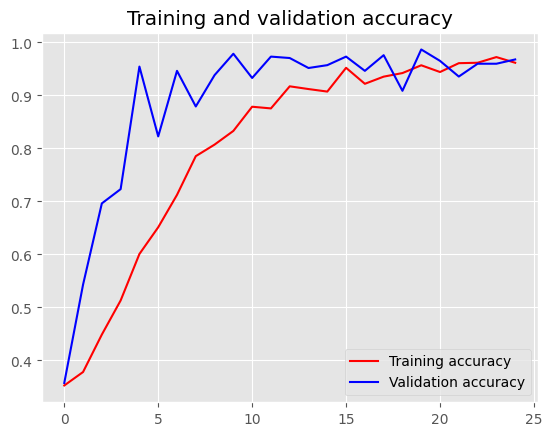

<Figure size 640x480 with 0 Axes>

In [15]:
# Plot Accuracy
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()


plt.show()

In [18]:
# Model evaluation
test_loss, test_acc = model.evaluate(validation_generator, verbose=2)
print(f'Accuracy: {test_acc:.4f}')

3/3 - 1s - 434ms/step - accuracy: 0.9677 - loss: 0.0661
Accuracy: 0.9677


We get high accuracy of 96.7%

**Prediction simulation**

Now, we want to conduct prediction experiment from uploaded photos to check the performance. We can upload our own hand gestures for checking the model real performance (Below, I have uploaded some photos of my own hand gestures).

Saving unseen_paper.jpeg to unseen_paper.jpeg


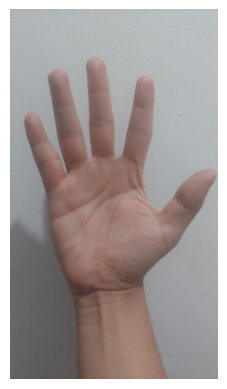

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step
Model prediction: paper


In [19]:
# Upload, display uploaded image, and predict
import io
from PIL import Image
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()  # Upload image manually

for fn in uploaded.keys():

  # ---------- DISPLAY IMAGE ----------
  image_bytes = uploaded[fn]  # Get image bytes

  img_display = Image.open(io.BytesIO(image_bytes)).convert("RGB")
  plt.imshow(img_display)
  plt.axis('off')
  plt.show()

  # ---------- PREPROCESS FOR MODEL ----------
  path = fn
  img = image.load_img(path, target_size=(150, 150))  # Resize image
  x = image.img_to_array(img)  # Convert to numpy array
  x = x / 255.0  # Normalize (IMPORTANT if training used rescale=1./255)
  x = np.expand_dims(x, axis=0)  # Add batch dimension

  images = np.vstack([x])  # Stack image

  # ---------- PREDICT ----------
  classes = model.predict(images, batch_size=10)

  # ---------- CONVERT TO LABEL ----------
  class_indices = train_generator.class_indices
  labels = dict((v, k) for k, v in class_indices.items())

  predicted_class = np.argmax(classes)

  print(f"Model prediction: {labels[predicted_class]}")

Saving unseen_scissor.jpeg to unseen_scissor.jpeg


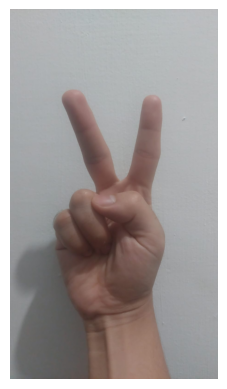

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Model prediction: scissors


In [20]:
# Upload, display uploaded image, and predict
uploaded = files.upload()  # Upload image manually

for fn in uploaded.keys():

  # ---------- DISPLAY IMAGE ----------
  image_bytes = uploaded[fn]  # Get image bytes

  img_display = Image.open(io.BytesIO(image_bytes)).convert("RGB")
  plt.imshow(img_display)
  plt.axis('off')
  plt.show()

  # ---------- PREPROCESS FOR MODEL ----------
  path = fn
  img = image.load_img(path, target_size=(150, 150))  # Resize image
  x = image.img_to_array(img)  # Convert to numpy array
  x = x / 255.0  # Normalize (IMPORTANT if training used rescale=1./255)
  x = np.expand_dims(x, axis=0)  # Add batch dimension

  images = np.vstack([x])  # Stack image

  # ---------- PREDICT ----------
  classes = model.predict(images, batch_size=10)

  # ---------- CONVERT TO LABEL ----------
  class_indices = train_generator.class_indices
  labels = dict((v, k) for k, v in class_indices.items())

  predicted_class = np.argmax(classes)

  print(f"Model prediction: {labels[predicted_class]}")

Saving unseen_stone.jpeg to unseen_stone.jpeg


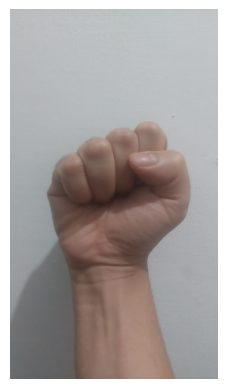

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Model prediction: rock


In [21]:
# Upload, display uploaded image, and predict
uploaded = files.upload()  # Upload image manually

for fn in uploaded.keys():

  # ---------- DISPLAY IMAGE ----------
  image_bytes = uploaded[fn]  # Get image bytes

  img_display = Image.open(io.BytesIO(image_bytes)).convert("RGB")
  plt.imshow(img_display)
  plt.axis('off')
  plt.show()

  # ---------- PREPROCESS FOR MODEL ----------
  path = fn
  img = image.load_img(path, target_size=(150, 150))  # Resize image
  x = image.img_to_array(img)  # Convert to numpy array
  x = x / 255.0  # Normalize (IMPORTANT if training used rescale=1./255)
  x = np.expand_dims(x, axis=0)  # Add batch dimension

  images = np.vstack([x])  # Stack image

  # ---------- PREDICT ----------
  classes = model.predict(images, batch_size=10)

  # ---------- CONVERT TO LABEL ----------
  class_indices = train_generator.class_indices
  labels = dict((v, k) for k, v in class_indices.items())

  predicted_class = np.argmax(classes)

  print(f"Model prediction: {labels[predicted_class]}")

It turns out the model can recognize and accurately figure out the sample photos.

**Conclusion**

We have built CNN model for classifying hand gesture images. The model has accuracy of 96.7%